In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform
import sys
sys.path.append('../hw1/')
import heat_rod as hr

# Set random seed for reproducibility
np.random.seed(42)

# Problem parameters
k = 2.3  # W/cm/°C
Tamb = 21.29  # °C
a = 0.95  # cm 
b = 0.95  # cm
L = 70  # cm
x_target = 38  # cm

# Distribution parameters for q = [Φ, h]ᵀ
# Φ ~ N(-15, 10) in W/cm²
phi_mean = -15
phi_var = 10
phi_std = np.sqrt(phi_var)

# h ~ U(5e-4, 0.0015) in W/cm²/°C
h_lower = 5e-4
h_upper = 0.0015

# Create the rod model
rod = hr.SteadyStateRod(a, b, None, k, None, Tamb, L)

print("="*60)
print("PROBLEM 3.1: Monte Carlo Analysis (Large Sample)")
print("="*60)

# Generate large number of samples for accurate estimate
N_large = 100000
phi_samples_large = np.random.normal(phi_mean, phi_std, N_large)
h_samples_large = np.random.uniform(h_lower, h_upper, N_large)

# Evaluate Ts at x=38 for each sample
Ts_samples_large = np.zeros(N_large)
for i in range(N_large[:]):
    Ts_samples_large[i] = rod.Ts(x_target, h=h_samples_large[i], k=k, 
                                  Phi=phi_samples_large[i], Tamb=Tamb)

# Calculate mean and variance
Ts_mean_true = np.mean(Ts_samples_large)
Ts_var_true = np.var(Ts_samples_large)

# # Calculate standard errors
# std_error_mean = np.std(Ts_samples_large) / np.sqrt(N_large)
# std_error_var = np.sqrt(2/N_large) * Ts_var_true  # Approximate for normal distribution

print(f"Based on {N_large:,} MC samples:")
print(f"𝔼[Ts] = {Ts_mean_true:.6f} °C")

print(f"\nvar[Ts] = {Ts_var_true:.6f} (°C)²")
print(f"std[Ts] = {Ts_var_true**.5:.6f} (°C)²")



PROBLEM 3.1: Monte Carlo Analysis (Large Sample)
Based on 100,000 MC samples:
𝔼[Ts] = 57.977335 °C

var[Ts] = 336.988485 (°C)²
std[Ts] = 18.357246 (°C)²


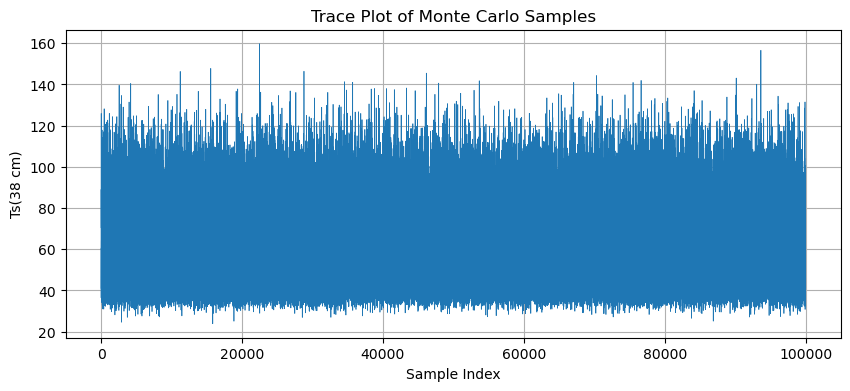

In [57]:
plt.figure(figsize=(10,4))
plt.plot(Ts_samples_large, linewidth=0.5)
plt.xlabel("Sample Index")
plt.ylabel("Ts(38 cm)")
plt.title("Trace Plot of Monte Carlo Samples")
plt.grid()
plt.show()

We have no visible drift and good sample spread across the temperature range. So, the MC algorithm is mixing well and our samples should well represent the posterior.

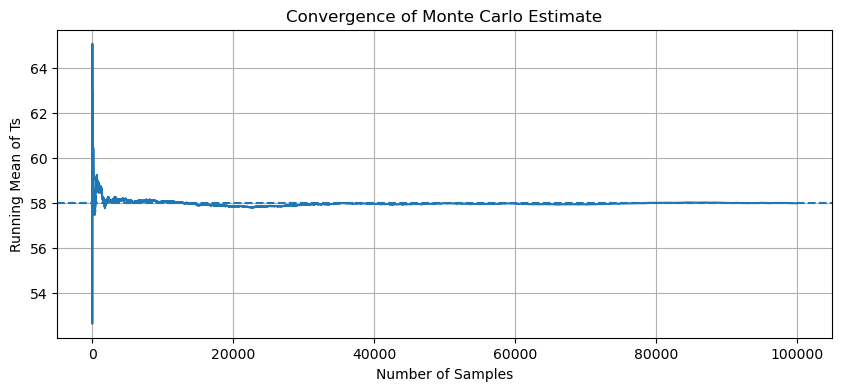

In [58]:
running_mean = np.cumsum(Ts_samples_large) / np.arange(1, N_large+1)

plt.figure(figsize=(10,4))
plt.plot(running_mean)
plt.axhline(Ts_mean_true, linestyle='--')
plt.xlabel("Number of Samples")
plt.ylabel("Running Mean of Ts")
plt.title("Convergence of Monte Carlo Estimate")
plt.grid()
plt.show()

Visually, the running mean stabilizes around 4000 samples, with not much noticable change after 4000 samples. So, by 100000, the samples should generally have stabilized (the posterior has been well sampled). We thus take 4000 as a burnin period, and remove those samples.

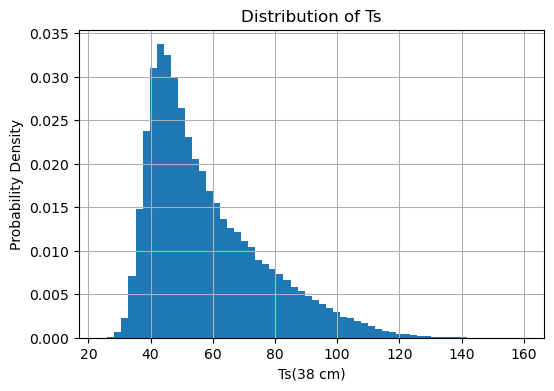

In [63]:
burnin = 4000
plt.figure(figsize=(6,4))
plt.hist(Ts_samples_large[burnin:], bins=60, density=True)
plt.xlabel("Ts(38 cm)")
plt.ylabel("Probability Density")
plt.title("Distribution of Ts")
plt.grid()
plt.show()


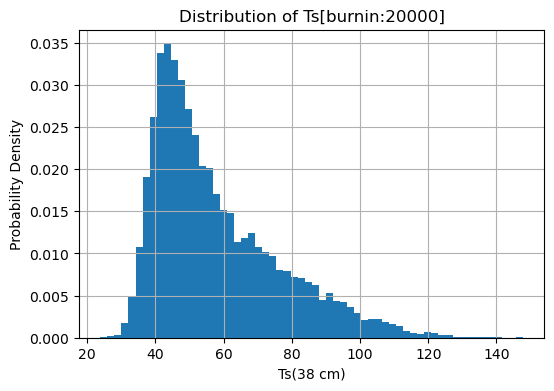

In [65]:
plt.figure(figsize=(6,4))
plt.hist(Ts_samples_large[burnin:20000], bins=60, density=True)
plt.xlabel("Ts(38 cm)")
plt.ylabel("Probability Density")
plt.title("Distribution of Ts[burnin:20000]")
plt.grid()
plt.show()


Visually, as mentioned above, after the burnin samples, there is minimal change to the posterior distribution. This is of course a qualitative description rather than a strong quantitative guarentee on the accuracy of our MC simulation.

In [74]:
Ts_mean_true = np.mean(Ts_samples_large[burnin:])
Ts_var_true = np.var(Ts_samples_large[burnin:])



print(f"Based on {N_large:,} MC samples:")
print(f"𝔼[Ts] = {Ts_mean_true:.6f} °C")

print(f"\nvar[Ts] = {Ts_var_true:.6f} (°C)²")
print(f"std[Ts] = {Ts_var_true**.5:.6f} (°C)²")


Based on 100,000 MC samples:
𝔼[Ts] = 57.972912 °C

var[Ts] = 336.684261 (°C)²
std[Ts] = 18.348958 (°C)²


A Monte Carlo simulation with N=100000 samples was performed, and we notice the running mean converges rapidly and stabilizes, demonstrating convergence of the estimator and the trace plot shows stationary fluctuations without drift, confirming the absensce of bias or sampling instability. With the standard deviation of the mean, we have a quantitative and the standard error of the mean is only about 18, for a mean of about 56 C, also indicating reasonable convergence on the mean of the data.

# 3.2

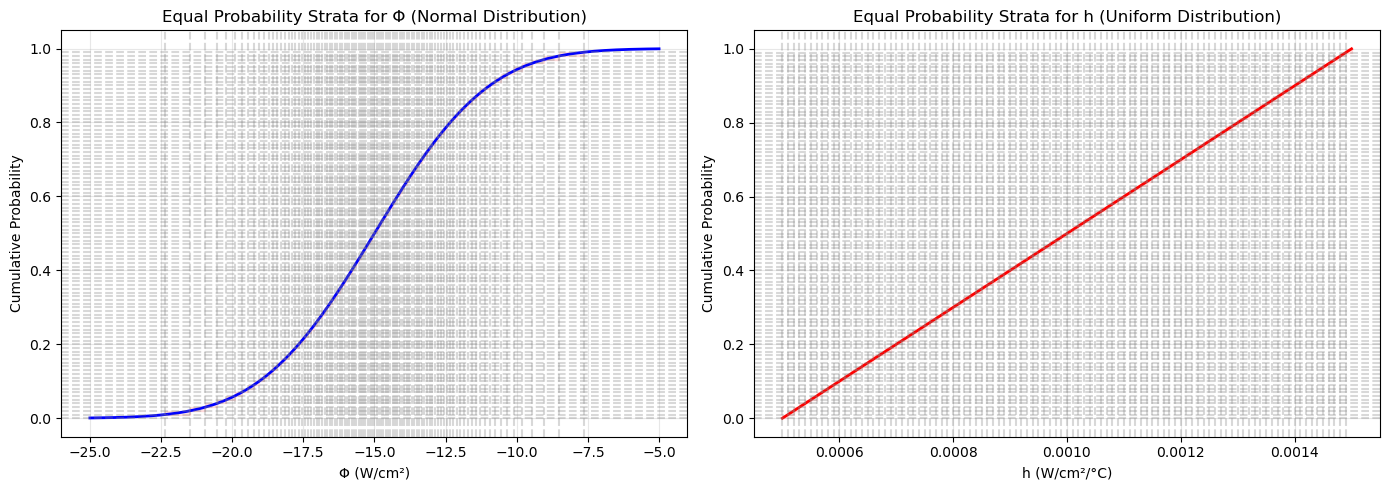

In [75]:
def lhs_samples_explicit(N, phi_mean, phi_std, h_lower, h_upper, seed = 42):
    """
    Generate Latin Hypercube Samples with explicit probability stratification
    """
    # Define the probability strata boundaries
    prob_bounds = np.linspace(0, 1, N+1)  # [0, 1/N, 2/N, ..., 1]
    
    u_phi = np.zeros(N)
    u_h = np.zeros(N)
    
    for i in range(N):
        # Lower and upper bounds of this probability stratum
        p_low = prob_bounds[i]
        p_high = prob_bounds[i+1]
        
        # Sample uniformly within this probability stratum
        u_phi[i] = np.random.uniform(p_low, p_high)
        u_h[i] = np.random.uniform(p_low, p_high)
    
    # Shuffle to break correlation
    np.random.seed(seed)  # for reproducibility
    np.random.shuffle(u_phi)
    np.random.shuffle(u_h)
    
    # Transform using inverse CDF
    phi_samples = norm.ppf(u_phi, loc=phi_mean, scale=phi_std)
    h_samples = h_lower + u_h * (h_upper - h_lower)
    
    return phi_samples, h_samples

# Demonstrate the difference
N_demo = 100
phi_mean, phi_std = -15, np.sqrt(10)
h_lower, h_upper = 5e-4, 0.0015

# Generate samples with corrected LHS
phi_lhs_correct, h_lhs_correct = lhs_samples_explicit(N_demo, phi_mean, phi_std, h_lower, h_upper)

# Visualize the probability strata
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot showing probability strata for normal distribution
ax1 = axes[0]
x_phi = np.linspace(-25, -5, 1000)
cdf_phi = norm.cdf(x_phi, phi_mean, phi_std)

ax1.plot(x_phi, cdf_phi, 'b-', linewidth=2, label='CDF of Φ')
for i in range(N_demo+1):
    prob_i = i/N_demo
    if i < N_demo:
        # Find parameter value at this CDF level
        x_i = norm.ppf(prob_i, phi_mean, phi_std)
        ax1.axhline(y=prob_i, color='gray', linestyle='--', alpha=0.3)
        ax1.axvline(x=x_i, color='gray', linestyle='--', alpha=0.3)
        
        # Highlight the probability strata
        ax1.fill_betweenx([prob_i, (i+1)/N_demo], 
                          norm.ppf(prob_i, phi_mean, phi_std),
                          norm.ppf((i+1)/N_demo, phi_mean, phi_std),
                          alpha=0.1, color='red')

ax1.set_xlabel('Φ (W/cm²)')
ax1.set_ylabel('Cumulative Probability')
ax1.set_title('Equal Probability Strata for Φ (Normal Distribution)')
ax1.grid(True, alpha=0.3)

# Plot showing probability strata for uniform distribution
ax2 = axes[1]
x_h = np.linspace(h_lower, h_upper, 1000)
cdf_h = (x_h - h_lower) / (h_upper - h_lower)

ax2.plot(x_h, cdf_h, 'r-', linewidth=2, label='CDF of h')
for i in range(N_demo+1):
    prob_i = i/N_demo
    if i < N_demo:
        # For uniform, parameter value is linear in probability
        x_i = h_lower + prob_i * (h_upper - h_lower)
        ax2.axhline(y=prob_i, color='gray', linestyle='--', alpha=0.3)
        ax2.axvline(x=x_i, color='gray', linestyle='--', alpha=0.3)
        
        # Highlight the probability strata
        ax2.fill_betweenx([prob_i, (i+1)/N_demo],
                          h_lower + prob_i * (h_upper - h_lower),
                          h_lower + ((i+1)/N_demo) * (h_upper - h_lower),
                          alpha=0.1, color='red')

ax2.set_xlabel('h (W/cm²/°C)')
ax2.set_ylabel('Cumulative Probability')
ax2.set_title('Equal Probability Strata for h (Uniform Distribution)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



PROBLEM 3.2: Comparison of MC vs LHS Sampling (N=100)


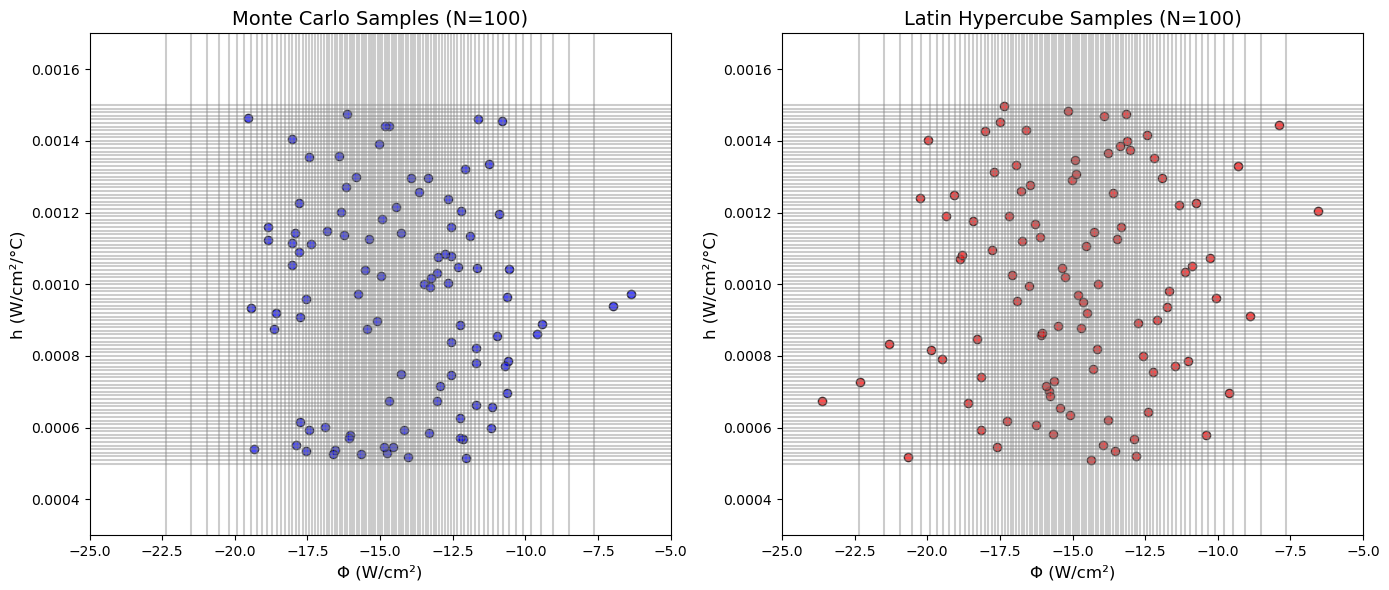

In [76]:

print("\n" + "="*60)
print("PROBLEM 3.2: Comparison of MC vs LHS Sampling (N=100)")
print("="*60)

N = 100

# MC samples
phi_mc = np.random.normal(phi_mean, phi_std, N)
h_mc = np.random.uniform(h_lower, h_upper, N)

# LHS samples
phi_lhs, h_lhs = lhs_samples_explicit(N, phi_mean, phi_std, h_lower, h_upper)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# MC samples plot
axes[0].scatter(phi_mc, h_mc, alpha=0.7, color='blue', edgecolors='black')
axes[0].set_xlabel('Φ (W/cm²)', fontsize=12)
axes[0].set_ylabel('h (W/cm²/°C)', fontsize=12)
axes[0].set_title(f'Monte Carlo Samples (N={N})', fontsize=14)
# axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([-25, -5])  # Adjust based on distribution
axes[0].set_ylim([h_lower - 0.0002, h_upper + 0.0002])

# LHS samples plot
axes[1].scatter(phi_lhs, h_lhs, alpha=0.7, color='red', edgecolors='black')
axes[1].set_xlabel('Φ (W/cm²)', fontsize=12)
axes[1].set_ylabel('h (W/cm²/°C)', fontsize=12)
axes[1].set_title(f'Latin Hypercube Samples (N={N})', fontsize=14)
# axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([-25, -5])
axes[1].set_ylim([h_lower - 0.0002, h_upper + 0.0002])

plt.tight_layout()
# Number of probability strata
num_boxes = N   # smaller number so the grid is visible

# Vertical lines for Φ probability strata
for i in range(num_boxes + 1):
    p = i / num_boxes
    x_val = norm.ppf(p, phi_mean, phi_std)
    axes[0].axvline(x=x_val, color='gray', linestyle='-', alpha=0.4)
    axes[1].axvline(x=x_val, color='gray', linestyle='-', alpha=0.4)

# Horizontal lines for h probability strata
for i in range(num_boxes + 1):
    p = i / num_boxes
    y_val = h_lower + p * (h_upper - h_lower)
    axes[0].axhline(y=y_val, color='gray', linestyle='-', alpha=0.4)
    axes[1].axhline(y=y_val, color='gray', linestyle='-', alpha=0.4)
plt.show()



# 3.3


PROBLEM 3.3: Histograms of Samples


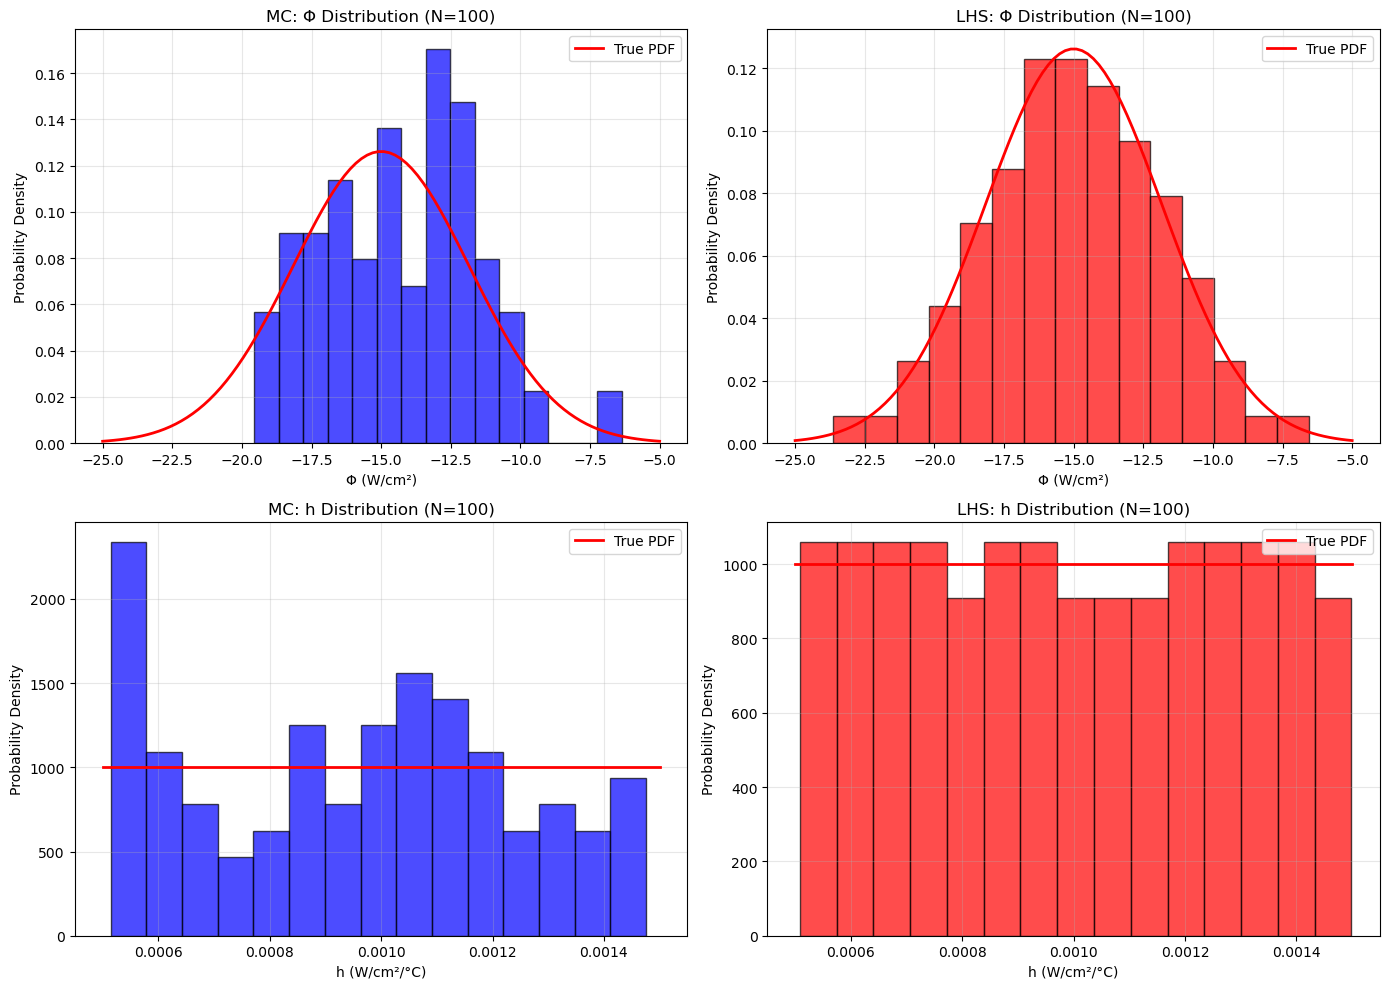

In [77]:

# ============================================================================
# PROBLEM 3.3: Histograms
# ============================================================================
print("\n" + "="*60)
print("PROBLEM 3.3: Histograms of Samples")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Φ histograms
axes[0, 0].hist(phi_mc, bins=15, density=True, alpha=0.7, color='blue', edgecolor='black')
x_phi = np.linspace(-25, -5, 100)
axes[0, 0].plot(x_phi, norm.pdf(x_phi, phi_mean, phi_std), 'r-', linewidth=2, label='True PDF')
axes[0, 0].set_xlabel('Φ (W/cm²)')
axes[0, 0].set_ylabel('Probability Density')
axes[0, 0].set_title(f'MC: Φ Distribution (N={N})')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(phi_lhs, bins=15, density=True, alpha=0.7, color='red', edgecolor='black')
axes[0, 1].plot(x_phi, norm.pdf(x_phi, phi_mean, phi_std), 'r-', linewidth=2, label='True PDF')
axes[0, 1].set_xlabel('Φ (W/cm²)')
axes[0, 1].set_ylabel('Probability Density')
axes[0, 1].set_title(f'LHS: Φ Distribution (N={N})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# h histograms
axes[1, 0].hist(h_mc, bins=15, density=True, alpha=0.7, color='blue', edgecolor='black')
x_h = np.linspace(h_lower, h_upper, 100)
axes[1, 0].plot(x_h, uniform.pdf(x_h, h_lower, h_upper - h_lower), 'r-', linewidth=2, label='True PDF')
axes[1, 0].set_xlabel('h (W/cm²/°C)')
axes[1, 0].set_ylabel('Probability Density')
axes[1, 0].set_title(f'MC: h Distribution (N={N})')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(h_lhs, bins=15, density=True, alpha=0.7, color='red', edgecolor='black')
axes[1, 1].plot(x_h, uniform.pdf(x_h, h_lower, h_upper - h_lower), 'r-', linewidth=2, label='True PDF')
axes[1, 1].set_xlabel('h (W/cm²/°C)')
axes[1, 1].set_ylabel('Probability Density')
axes[1, 1].set_title(f'LHS: h Distribution (N={N})')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


The histograms generated using Monte Carlo (MC) and Latin Hypercube Sampling (LHS) both approximate the underlying marginal distributions of the input variables $\phi$ and $h$. For $\phi$, the histograms should resemble a normal distribution with mean −15 and variance 10, while for 
$h$, they should approximate the uniform distribution on [$5×10^{−4}, 1.5×10^{−3}]. However, because the sample size is relatively small (N=100), the Monte Carlo histograms often exhibit noticeable clustering and gaps. This occurs because purely random sampling may oversample some regions of the distribution while undersampling others.

In contrast, the LHS histograms tend to appear more evenly distributed across the support of each variable. This occurs because LHS stratifies the probability space into N equally probable intervals and forces exactly one sample to be drawn from each interval. As a result, LHS provides better coverage of the marginal distributions and reduces sampling variability compared to standard Monte Carlo sampling.

Overall, while both sampling methods approximate the correct distributions, LHS typically produces histograms that more closely resemble the true densities with fewer samples due to its stratified sampling strategy.

# 3.4 & 3.5

In [78]:

print("\n" + "="*60)
print("PROBLEMS 3.4 & 3.5: Estimates with N=100")
print("="*60)

# Calculate Ts for MC samples
Ts_mc = np.zeros(N)
for i in range(N):
    Ts_mc[i] = rod.Ts(x_target, h=h_mc[i], k=k, Phi=phi_mc[i], Tamb=Tamb)

# Calculate Ts for LHS samples
Ts_lhs = np.zeros(N)
for i in range(N):
    Ts_lhs[i] = rod.Ts(x_target, h=h_lhs[i], k=k, Phi=phi_lhs[i], Tamb=Tamb)

# MC estimates
Ts_mean_mc = np.mean(Ts_mc)
Ts_var_mc = np.var(Ts_mc)

# LHS estimates
Ts_mean_lhs = np.mean(Ts_lhs)
Ts_var_lhs = np.var(Ts_lhs)

print(f"Monte Carlo (N={N}):")
print(f"  𝔼[Ts] = {Ts_mean_mc:.6f} °C")
print(f"  var[Ts] = {Ts_var_mc:.6f} (°C)²")

print(f"\nLatin Hypercube Sampling (N={N}):")
print(f"  𝔼[Ts] = {Ts_mean_lhs:.6f} °C")
print(f"  var[Ts] = {Ts_var_lhs:.6f} (°C)²")

print(f"\nReference (N={N_large:,}):")
print(f"  𝔼[Ts] = {Ts_mean_true:.6f} °C")
print(f"  var[Ts] = {Ts_var_true:.6f} (°C)²")

# Calculate errors
print(f"\nErrors relative to large-sample reference:")
print(f"  MC mean error: {abs(Ts_mean_mc - Ts_mean_true):.6f} °C ({abs(Ts_mean_mc - Ts_mean_true)/Ts_mean_true*100:.2f}%)")
print(f"  LHS mean error: {abs(Ts_mean_lhs - Ts_mean_true):.6f} °C ({abs(Ts_mean_lhs - Ts_mean_true)/Ts_mean_true*100:.2f}%)")
print(f"  MC var error: {abs(Ts_var_mc - Ts_var_true):.6f} (°C)² ({abs(Ts_var_mc - Ts_var_true)/Ts_var_true*100:.2f}%)")
print(f"  LHS var error: {abs(Ts_var_lhs - Ts_var_true):.6f} (°C)² ({abs(Ts_var_lhs - Ts_var_true)/Ts_var_true*100:.2f}%)")



PROBLEMS 3.4 & 3.5: Estimates with N=100
Monte Carlo (N=100):
  𝔼[Ts] = 58.963071 °C
  var[Ts] = 377.502056 (°C)²

Latin Hypercube Sampling (N=100):
  𝔼[Ts] = 58.383613 °C
  var[Ts] = 366.118399 (°C)²

Reference (N=100,000):
  𝔼[Ts] = 57.972912 °C
  var[Ts] = 336.684261 (°C)²

Errors relative to large-sample reference:
  MC mean error: 0.990159 °C (1.71%)
  LHS mean error: 0.410701 °C (0.71%)
  MC var error: 40.817795 (°C)² (12.12%)
  LHS var error: 29.434139 (°C)² (8.74%)


# 3.6

In [81]:
# ============================================================================
# PROBLEM 3.6: Comparison of MC vs LHS Performance
# ============================================================================

print("\n" + "="*60)
print("PROBLEM 3.6: MC vs LHS Performance Comparison")
print("="*60)

def evaluate_method(N, seed):
    """
    Run MC and LHS experiments for a given N and seed
    """
    np.random.seed(seed)

    # Monte Carlo samples
    phi_mc = np.random.normal(phi_mean, phi_std, N)
    h_mc = np.random.uniform(h_lower, h_upper, N)

    # LHS samples
    phi_lhs, h_lhs = lhs_samples_explicit(N, phi_mean, phi_std, h_lower, h_upper, seed = seed)

    # Evaluate Ts
    Ts_mc = np.zeros(N)
    Ts_lhs = np.zeros(N)

    for i in range(N):
        Ts_mc[i] = rod.Ts(x_target, h=h_mc[i], k=k, Phi=phi_mc[i], Tamb=Tamb)
        Ts_lhs[i] = rod.Ts(x_target, h=h_lhs[i], k=k, Phi=phi_lhs[i], Tamb=Tamb)

    # Statistics
    mc_mean = np.mean(Ts_mc)
    mc_var = np.var(Ts_mc)

    lhs_mean = np.mean(Ts_lhs)
    lhs_var = np.var(Ts_lhs)

    return mc_mean, mc_var, lhs_mean, lhs_var

# Different sample sizes to test
N_values = [10, 50, 100, 200, 400, 600, 800]

# Different seeds
seeds = range(1,11)

# Store summary results
summary_results = []

for N_test in N_values:
    
    mc_means = []
    mc_vars = []
    
    lhs_means = []
    lhs_vars = []
    
    for seed in seeds:
        mc_mean, mc_var, lhs_mean, lhs_var = evaluate_method(N_test, seed)

        mc_means.append(mc_mean)
        mc_vars.append(mc_var)

        lhs_means.append(lhs_mean)
        lhs_vars.append(lhs_var)

    # Compute averages across seeds
    mc_mean_of_means = np.mean(mc_means)
    mc_mean_of_vars = np.mean(mc_vars)
    mc_var_of_vars = np.var(mc_vars)

    lhs_mean_of_means = np.mean(lhs_means)
    lhs_mean_of_vars = np.mean(lhs_vars)
    lhs_var_of_vars = np.var(lhs_vars)

    summary_results.append([
        N_test,
        mc_mean_of_means,
        mc_mean_of_vars,
        mc_var_of_vars,
        lhs_mean_of_means,
        lhs_mean_of_vars,
        lhs_var_of_vars
    ])


# ==========================================================
# Print Summary Table
# ==========================================================

print(f"\nReference (N={N_large:,}):")
print(f"  𝔼[Ts] = {Ts_mean_true:.6f} °C")
print(f"  var[Ts] = {Ts_var_true:.6f} (°C)²")


print("\n" + "="*70)
print("SUMMARY OF MC vs LHS PERFORMANCE (Averaged Over Seeds)")
print("="*70)

print(f"{'N':<8}{'MC mean':<15}{'MC var':<15}{'MC var variance':<15}{'LHS mean':<15}{'LHS var':<15}{'LHS var variance'},{'MC mean error'}, {'LHS mean error'}")

for row in summary_results:
    mcerror = (row[1] - Ts_mean_true)/Ts_mean_true
    lhserror = (row[4] - Ts_mean_true)/ Ts_mean_true


    print(f"{row[0]:<8}{row[1]:<15.5f}{row[2]:<15.5f}{row[3]:<15.5f}{row[4]:<15.5f}{row[5]:<15.5f}{row[6]:<15.5f}{mcerror:<15.5f}{lhserror:<15.5f}")


PROBLEM 3.6: MC vs LHS Performance Comparison

Reference (N=100,000):
  𝔼[Ts] = 57.972912 °C
  var[Ts] = 336.684261 (°C)²

SUMMARY OF MC vs LHS PERFORMANCE (Averaged Over Seeds)
N       MC mean        MC var         MC var varianceLHS mean       LHS var        LHS var variance,MC mean error, LHS mean error
10      58.41422       345.48698      51529.66629    57.99939       333.08348      10681.46977    0.00761        0.00046        
50      57.41362       327.95028      2565.41155     58.16888       347.04505      2956.49978     -0.00965       0.00338        
100     58.63580       359.54839      2652.89786     58.24108       354.19917      1113.90159     0.01143        0.00463        
200     57.84541       339.74196      694.38060      57.99705       326.01991      435.99043      -0.00220       0.00042        
400     57.95722       338.17556      427.46724      58.03837       336.12325      359.32074      -0.00027       0.00113        
600     57.68274       329.72017      354.5222

var variance is the variance of the samples' variance, evaluated across seeds.

In [80]:

print(f"\nReference (N={N_large:,}):")
print(f"  𝔼[Ts] = {Ts_mean_true:.6f} °C")
print(f"  var[Ts] = {Ts_var_true:.6f} (°C)²")


Reference (N=100,000):
  𝔼[Ts] = 57.972912 °C
  var[Ts] = 336.684261 (°C)²


Latin Hypercube Sampling (LHS) is more efficient than standard Monte Carlo for small and moderate numbers of samples. It ensures better coverage of the input parameter space, producing estimates of the expectation and variance that are, in general, better representative of the input parameter space (as given by the reference large-sample MCMC method). For large N, both methods converge, but LHS still tends to have slightly reduced error (mean Ts vs true Ts) and variance (variance of Ts, as well as the variance across seeds/samples, var variance).